## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Ingreso mensual (`ingreso_mensual`), monto solicitado (`monto_solicitado`), historial moroso (`tiene_historial_moroso`). |
| **Acciones (A)** | Aprobar solicitud (`"aprobar"`), Aprobar con condiciones (`"aprobar con condiciones"`), Rechazar solicitud (`"rechazar"`). |
| **Entorno (E)** | Sistema de evaluación crediticia del banco y base de datos financiera del cliente. |
| **Objetivo** | Maximizar la colocación de créditos rentables reduciendo al mínimo el riesgo de impago y mora. |
| **Medida de desempeño (P)** | Tasa de morosidad de la cartera aprobada, monto total prestado con retorno exitoso y porcentaje de clientes satisfechos. |


### Justificación de las reglas
Las reglas priorizan la sostenibilidad financiera del banco. Un historial moroso previo limita la capacidad de endeudamiento a un máximo del 30% del ingreso mensual y exige aval. Para clientes sin antecedentes morosos, una relación monto/ingreso de hasta 40% es financieramente sostenible para aprobación directa, entre 40% y 70% requiere garantías suplementarias, y más del 70% representa un riesgo inaceptable de sobreendeudamiento.

In [10]:
### Código
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    if ingreso_mensual <= 0:
        return "rechazar", "Ingreso mensual invalido o igual a cero"
    
    relacion = monto_solicitado / ingreso_mensual
    
    if tiene_historial_moroso:
        if relacion <= 0.3:
            return "aprobar con condiciones", f"Relacion monto/ingreso baja ({relacion:.2f}), pero presenta historial moroso (requiere aval)"
        else:
            return "rechazar", f"Relacion monto/ingreso alta ({relacion:.2f}) acompañada de historial moroso"
    else:
        if relacion <= 0.4:
            return "aprobar", f"Relacion monto/ingreso optima ({relacion:.2f}) y sin historial moroso"
        elif relacion <= 0.7:
            return "aprobar con condiciones", f"Relacion monto/ingreso moderada ({relacion:.2f}), requiere garantia adicional"
        else:
            return "rechazar", f"Relacion monto/ingreso excesiva ({relacion:.2f}) que representa sobreendeudamiento"

In [11]:
### Simulación y pruebas
casos_prueba = [
    (5000, 1500, False),  # Relación 0.30 -> Aprobar
    (5000, 2000, False),  # Relación 0.40 -> Caso borde exacto -> Aprobar
    (5000, 3000, False),  # Relación 0.60 -> Aprobar con condiciones
    (4000, 1200, True),   # Relación 0.30 -> Caso borde moroso -> Aprobar con condiciones
    (4000, 2000, True),   # Relación 0.50 -> Rechazar por morosidad
    (3000, 2500, False)   # Relación 0.83 -> Rechazar por monto alto
]

print("--- RESULTADOS DE SIMULACIÓN DE CRÉDITO ---")
for i, (ingreso, monto, moroso) in enumerate(casos_prueba, 1):
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Caso {i} [Ingreso: S/{ingreso}, Monto: S/{monto}, Moroso: {moroso}]:")
    print(f"  -> Decisión: {accion.upper()} | Motivo: {motivo}\n")

--- RESULTADOS DE SIMULACIÓN DE CRÉDITO ---
Caso 1 [Ingreso: S/5000, Monto: S/1500, Moroso: False]:
  -> Decisión: APROBAR | Motivo: Relacion monto/ingreso optima (0.30) y sin historial moroso

Caso 2 [Ingreso: S/5000, Monto: S/2000, Moroso: False]:
  -> Decisión: APROBAR | Motivo: Relacion monto/ingreso optima (0.40) y sin historial moroso

Caso 3 [Ingreso: S/5000, Monto: S/3000, Moroso: False]:
  -> Decisión: APROBAR CON CONDICIONES | Motivo: Relacion monto/ingreso moderada (0.60), requiere garantia adicional

Caso 4 [Ingreso: S/4000, Monto: S/1200, Moroso: True]:
  -> Decisión: APROBAR CON CONDICIONES | Motivo: Relacion monto/ingreso baja (0.30), pero presenta historial moroso (requiere aval)

Caso 5 [Ingreso: S/4000, Monto: S/2000, Moroso: True]:
  -> Decisión: RECHAZAR | Motivo: Relacion monto/ingreso alta (0.50) acompañada de historial moroso

Caso 6 [Ingreso: S/3000, Monto: S/2500, Moroso: False]:
  -> Decisión: RECHAZAR | Motivo: Relacion monto/ingreso excesiva (0.83) que repre

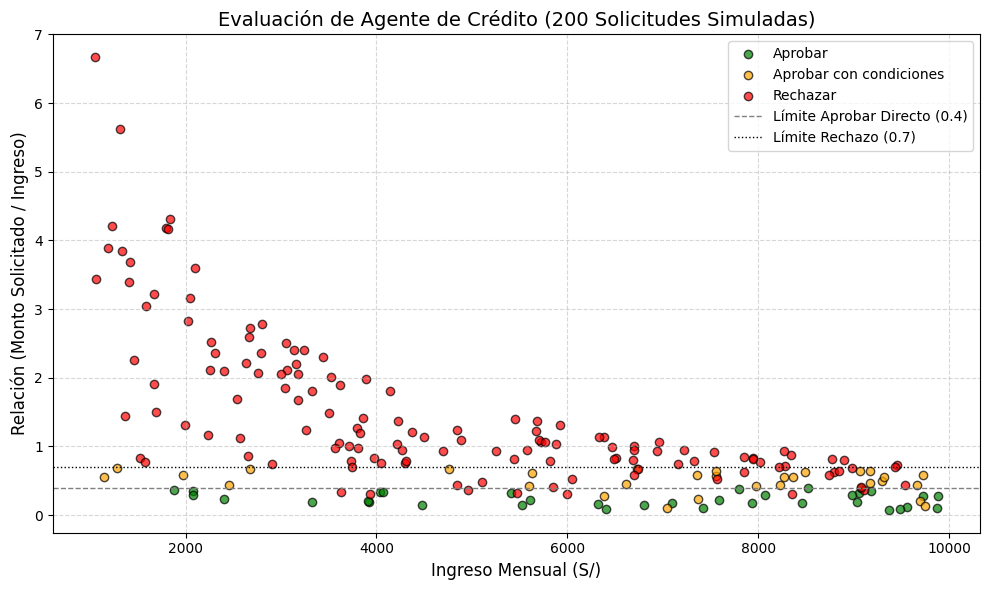

In [12]:
### Visualización
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar 200 solicitudes aleatorias
ingresos = np.random.uniform(1000, 10000, 200)
montos = np.random.uniform(500, 8000, 200)
historiales = np.random.choice([True, False], size=200, p=[0.3, 0.7])

relaciones = []
acciones = []

for ing, mon, mor in zip(ingresos, montos, historiales):
    rel = mon / ing
    acc, _ = agente_credito(ing, mon, mor)
    relaciones.append(rel)
    acciones.append(acc)

relaciones = np.array(relaciones)
acciones = np.array(acciones)

mapa_colores = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

plt.figure(figsize=(10, 6))

for accion, color in mapa_colores.items():
    mask = acciones == accion
    plt.scatter(
        ingresos[mask], 
        relaciones[mask], 
        c=color, 
        label=accion.capitalize(), 
        alpha=0.7, 
        edgecolors='k'
    )

plt.axhline(0.4, color='gray', linestyle='--', linewidth=1, label='Límite Aprobar Directo (0.4)')
plt.axhline(0.7, color='black', linestyle=':', linewidth=1, label='Límite Rechazo (0.7)')

plt.title('Evaluación de Agente de Crédito (200 Solicitudes Simuladas)', fontsize=14)
plt.xlabel('Ingreso Mensual (S/)', fontsize=12)
plt.ylabel('Relación (Monto Solicitado / Ingreso)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()